#Notebook Sesión 1:

#Calculo de probabilidades

El dataset 'penguins' contiene mediciones para 344 pingüinos de tres especies diferentes (Adelie, Chinstrap y Gentoo) de tres islas en el archipiélago Palmer (Antártida). Cada pingüino incluye las siguientes características:

*   **species**: La especie del pingüino (Adelie, Chinstrap, Gentoo).
*   **island**: La isla donde se encontró el pingüino (Torgersen, Biscoe, Dream).
*   **bill_length_mm**: Longitud del pico en milímetros.
*   **bill_depth_mm**: Profundidad del pico en milímetros.
*   **flipper_length_mm**: Longitud de la aleta en milímetros.
*   **body_mass_g**: Masa corporal en gramos.
*   **sex**: El sexo del pingüino (macho o hembra).

Este dataset es comúnmente utilizado para tareas de exploración de datos, visualización y clasificación, similar al famoso dataset Iris, pero con un contexto más biológico.

##Contexto:
Antes de entrenar un modelo de clasificación para predecir la especie de un pinguino, necesitamos entender la distribución conjunta de nuestras variables categóricas.
Usando la tabla de contingencia (pd.crosstab) que acaban de generar con Ω = 333 registros

In [9]:
#Crea tu código acá
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Cargar el dataset y limpiar valores nulos (Nuestro Universo)
df = sns.load_dataset("penguins").dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


##Problema 1:

Calcule:



*   Prob. de que el pingüino NO sea de la especie Adelie
*   Prob. de que sea Adelie Y viva en la isla Dream.
*   Prob. de que sea Adelie O viva en la isla Dream.
*   Prob. de que sea Adelie, PERO NO viva en Dream.



      

##Ejemplo 1:
Sea:
*   **Evento A:** La especie del pingüino es 'Adelie'.
*   **Evento B:** La masa corporal del pingüino (`body_mass_g`) es mayor a 4000 gramos.

Las preguntas respondidas son:

1.  **Tamaño del espacio muestral:** ¿Cuál es el número total de pingüinos en el dataset limpio?
2.  **P(A):** ¿Cuál es la probabilidad de que un pingüino elegido al azar sea de la especie Adelie?
3.  **P(B):** ¿Cuál es la probabilidad de que un pingüino elegido al azar tenga una masa corporal superior a 4000g?
4.  **P(A ∩ B):** ¿Cuál es la probabilidad de que un pingüino sea de la especie Adelie Y tenga una masa corporal superior a 4000g?
5.  **P(A U B):** ¿Cuál es la probabilidad de que un pingüino sea de la especie Adelie O tenga una masa corporal superior a 4000g?
6.  **P(A^c):** ¿Cuál es la probabilidad de que un pingüino NO sea de la especie Adelie?
7.  **P(A - B):** ¿Cuál es la probabilidad de que un pingüino sea de la especie Adelie pero NO tenga una masa corporal superior a 4000g?

In [22]:
#Tabla de contingencia

df = sns.load_dataset('penguins').dropna()

tabla_rpobabilidad = pd.crosstab(
    index = df['species'],
    columns = df['island'],
    margins = True,
    margins_name = 'Total'
)

#   Prob. de que el pingüino NO sea de la especie Adelie
#   Prob. de que sea Adelie Y viva en la isla Dream.
#   Prob. de que sea Adelie O viva en la isla Dream.
#   Prob. de que sea Adelie, PERO NO viva en Dream.

print(tabla_rpobabilidad)

# 1
print((1 - (np.sum(tabla_rpobabilidad.loc['Adelie','Total'])) / len(df)) * 100, "%")
# 2
print((tabla_rpobabilidad.loc['Adelie', 'Dream'] / len(df)) * 100, "%")
# 3 64%

# 4 27%
# print(((tabla_rpobabilidad.loc['Adelie', 'Dream'] + tabla_rpobabilidad.loc['Adelie', 'Torgersen']) / len(df)) * 100, "%")

island     Biscoe  Dream  Torgersen  Total
species                                   
Adelie         44     55         47    146
Chinstrap       0     68          0     68
Gentoo        119      0          0    119
Total         163    123         47    333
56.15615615615616 %
16.516516516516518 %
30.630630630630627 %


In [8]:
# @title
import seaborn as sns
import pandas as pd

# 1. Cargar el dataset integrado y limpiar valores nulos para un espacio muestral perfecto
df = sns.load_dataset('penguins').dropna()

# Definir el tamaño del espacio muestral (|Ω|)
omega = len(df)
print(f"Tamaño del espacio muestral (Total de pingüinos): {omega}\n")

# 2. Definir los Eventos como Máscaras Booleanas
evento_A = df['species'] == 'Adelie'
evento_B = df['body_mass_g'] > 4000

# --- PROBABILIDAD MARGINAL P(A) y P(B) ---
prob_A = evento_A.mean()
prob_B = evento_B.mean()
print(f"P(A) [Especie Adelie]: {prob_A:.4f}")
print(f"P(B) [Peso > 4000g]: {prob_B:.4f}\n")

# --- INTERSECCIÓN P(A ∩ B) ---
# En Python, la intersección lógica es el operador '&'
prob_A_inter_B = (evento_A & evento_B).mean()
print(f"P(A ∩ B) [Adelie Y pesa > 4000g]: {prob_A_inter_B:.4f}\n")

# --- UNIÓN P(A U B) ---
# En Python, la unión lógica es el operador '|'
prob_A_union_B_empirica = (evento_A | evento_B).mean()
# Comprobación matemática del axioma
prob_A_union_B_teorica = prob_A + prob_B - prob_A_inter_B

print(f"P(A U B) Empírica (con Python '|'): {prob_A_union_B_empirica:.4f}")
print(f"P(A U B) Teórica (Fórmula Matemática): {prob_A_union_B_teorica:.4f}")
assert round(prob_A_union_B_empirica, 4) == round(prob_A_union_B_teorica, 4)
print("- ¡El axioma de la adición se cumple!\n")

# --- COMPLEMENTO P(A^c) ---
# En Python, la negación lógica es el operador '~'
prob_A_comp_empirica = (~evento_A).mean()
prob_A_comp_teorica = 1 - prob_A

print(f"P(A^c) Empírica (Pingüinos que NO son Adelie): {prob_A_comp_empirica:.4f}")
print(f"P(A^c) Teórica (1 - P(A)): {prob_A_comp_teorica:.4f}\n")

# --- DIFERENCIA P(A - B) ---
# En conjuntos: P(A ∩ B^c)
prob_A_dif_B_empirica = (evento_A & ~evento_B).mean()
prob_A_dif_B_teorica = prob_A - prob_A_inter_B

print(f"P(A - B) Empírica (Es Adelie pero NO pesa > 4000g): {prob_A_dif_B_empirica:.4f}")
print(f"P(A - B) Teórica (P(A) - P(A ∩ B)): {prob_A_dif_B_teorica:.4f}")

Tamaño del espacio muestral (Total de pingüinos): 333

P(A) [Especie Adelie]: 0.4384
P(B) [Peso > 4000g]: 0.5015

P(A ∩ B) [Adelie Y pesa > 4000g]: 0.1021

P(A U B) Empírica (con Python '|'): 0.8378
P(A U B) Teórica (Fórmula Matemática): 0.8378
- ¡El axioma de la adición se cumple!

P(A^c) Empírica (Pingüinos que NO son Adelie): 0.5616
P(A^c) Teórica (1 - P(A)): 0.5616

P(A - B) Empírica (Es Adelie pero NO pesa > 4000g): 0.3363
P(A - B) Teórica (P(A) - P(A ∩ B)): 0.3363


##Problema 2:
El dataset 'tips' contiene información sobre propinas recibidas en un restaurante. Este dataset es comúnmente utilizado para análisis exploratorios, regresión y clasificación, y es excelente para demostrar conceptos de visualización de datos.

Cada entrada en el dataset incluye las siguientes características:

*   **total_bill**: El costo total de la comida en dólares.
*   **tip**: La cantidad de la propina en dólares.
*   **sex**: El sexo de la persona que pagó la cuenta (Male, Female).
*   **smoker**: Si la persona que pagó la cuenta es fumadora (Yes, No).
*   **day**: El día de la semana en que se realizó la transacción (Thur, Fri, Sat, Sun).
*   **time**: El momento del día en que se realizó la transacción (Lunch, Dinner).
*   **size**: El tamaño del grupo en la mesa.



### Problema de Probabilidad con el Dataset 'Tips'

El dataset 'tips' contiene información sobre las propinas dadas en un restaurante. Vamos a analizar la probabilidad de ciertos eventos.

**Definamos los siguientes eventos:**
*   **Evento A:** El cliente que paga la cuenta es fumador (`smoker == 'Yes'`).
*   **Evento B:** La cuenta total (`total_bill`) es superior a la media de todas las cuentas.

**Con base en estas definiciones, responde las siguientes preguntas:**

1.  **P(A):** ¿Cuál es la probabilidad de que un cliente elegido al azar sea fumador?
2.  **P(B):** ¿Cuál es la probabilidad de que la cuenta total sea superior a la media?
3.  **P(A ∩ B):** ¿Cuál es la probabilidad de que un cliente sea fumador Y que la cuenta total sea superior a la media?
4.  **P(A U B):** ¿Cuál es la probabilidad de que un cliente sea fumador O que la cuenta total sea superior a la media?
5.  **P(A^c):** ¿Cuál es la probabilidad de que un cliente NO sea fumador?

In [ ]:
#Crea tu código acá
import seaborn as sns
import pandas as pd

# 1. Cargar el dataset y limpiar valores nulos (Nuestro Universo)
df = sns.load_dataset("tips").dropna()
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#Probabilidad Condicional

##Problema 3:
**El Contexto Analítico:**
En *Machine Learning*, la probabilidad condicional es la base de cómo un algoritmo "aprende". Cada vez que le damos una nueva variable (característica o *feature*) al modelo, reducimos nuestra incertidumbre porque encogemos nuestro espacio muestral ($\Omega$) original.

**El Reto:**
Observemos la matriz de contingencia de nuestros pingüinos. Supongamos que estamos programando un dron explorador en la Antártida.

1. **Probabilidad A Priori (Marginal):** Si el dron detecta un pingüino al azar en cualquier parte, sin saber la isla, ¿cuál es la probabilidad de que sea de la especie *Chinstrap*?
2. **Probabilidad Condicional:** Ahora el sensor GPS del dron nos confirma que acaba de aterrizar en la isla **Dream**. Dado que ya sabemos esta nueva información, ¿cuál es la probabilidad actualizada de que la silueta que vemos sea un *Chinstrap*?



## Problema 4:



*   **Evento A:** El cliente que paga la cuenta es fumador.
*   **Evento B:** La cuenta total es superior a \$19.79.

**Responde a las siguientes preguntas, justificando tu respuesta con los valores de probabilidad obtenidos:**

1.  Si el gerente quiere identificar clientes que potencialmente gastan más \$19.79, ¿es el hecho de ser fumador un buen indicador? ¿Por qué?
2.  Un mesero tiene una mesa. Si el cliente es fumador, ¿cómo cambia la probabilidad de que su cuenta sea superior a \$19.79 (en comparación con un cliente al azar)?
3.  ¿Qué tan común es encontrar clientes que no fuman y tienen una cuenta por debajo de \$19.79?
4.  Basado en estos datos, ¿qué información podrías darle al gerente para entender mejor los patrones de gasto y el comportamiento de los fumadores en su restaurante?

In [ ]:
##Crea tu código acá

#Teorema de la probabilidad total

El dataset 'taxis' contiene información sobre viajes en taxi. Es útil para análisis de viajes, patrones de uso, y estadísticas relacionadas con el transporte. Aunque el dataset puede variar, comúnmente incluye columnas como:

*   **pickup**: Fecha y hora de inicio del viaje.
*   **dropoff**: Fecha y hora de finalización del viaje.
*   **passengers**: Número de pasajeros en el viaje.
*   **distance**: Distancia total recorrida en el viaje.
*   **fare**: Tarifa base del viaje.
*   **tip**: Cantidad de propina dada.
*   **tolls**: Peajes pagados.
*   **total**: Monto total pagado por el viaje.

Este dataset es ideal para explorar la distribución de variables numéricas, patrones de tiempo y relaciones entre los diferentes aspectos de un viaje en taxi.

##Problema 5

###Teorema de la Probabilidad Total en Movilidad Urbana

**El Contexto Analítico:**
Como científicos de datos de la Comisión de Taxis de Nueva York (TLC), necesitamos reportar métricas globales de la ciudad. Sin embargo, la ciudad está fragmentada en diferentes "ecosistemas" que se comportan de forma completamente distinta.

Para calcular una probabilidad global $\mathbb{P}[A]$, no podemos simplemente sacar un promedio de todos los datos. Debemos usar el **Teorema de la Probabilidad Total**, ponderando la probabilidad condicional de cada subgrupo por su peso real en el mercado:
$$\mathbb{P}[A] = \sum_{i=1}^{n} \mathbb{P}[A \mid B_i] \mathbb{P}[B_i]$$



### Retos Analíticos: Aplicando el Teorema

Usando los resultados impresos en la celda anterior y sus calculadoras (o celdas de código nuevas), resuelvan:

**Pregunta 1: La Tasa Global de Propinas Altas (El Sesgo del Efectivo)**
El sindicato de conductores quiere saber la probabilidad global de recibir una propina mayor a **\$5** en cualquier viaje al azar ($\mathbb{P}[\text{Propina}]$). Saben que en efectivo casi nadie deja propina registrada en el sistema. Utilicen la partición de métodos de pago para calcular la probabilidad total exacta. ¿Por qué promediar las dos probabilidades condicionales directamente sería un error?

**Pregunta 2: Proyección de Ingresos por Peajes (Ecosistemas Vehiculares)**
El departamento de infraestructura de la ciudad está proyectando sus ingresos. Necesitan saber la probabilidad de que un taxi (sin importar su color) cruce un peaje ($\mathbb{P}[\text{Peaje}]$). Usen el Teorema de la Probabilidad Total con la partición de colores (Yellow/Green).



**Pregunta 3: Logística y Distancias (La Paradoja de Manhattan)**

Una empresa de mantenimiento de vehículos quiere estimar el desgaste de la flota. Les interesa la probabilidad total de que un viaje sea "Largo" (> 10 millas). Al ver los datos, notarán que la probabilidad de un viaje largo desde *Queens* es altísima (por los aeropuertos), pero la probabilidad de un viaje largo desde *Manhattan* es minúscula. Calculen la $\mathbb{P}[\text{Viaje Largo}]$ global. ¿Quién "arrastra" la probabilidad total hacia su lado y por qué?

In [ ]:
# tu código
import seaborn as sns
import pandas as pd

# Cargamos el dataset y limpiamos nulos
df = sns.load_dataset('taxis').dropna()

df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


#Teorema de Bayes



## Problema 6
**El Paradigma Bayesiano:**
En estadística tradicional, calculamos qué tan probable es un evento dado un escenario inicial ($P(\text{Efecto} \mid \text{Causa})$). Pero en Ciencia de Datos, los modelos predictivos operan al revés: observamos el dato final (la variable objetivo) y necesitamos adivinar de dónde vino. El Teorema de Bayes es el motor matemático que nos permite invertir esta dirección:

$$\mathbb{P}[\text{Causa} \mid \text{Efecto}] = \frac{\mathbb{P}[\text{Efecto} \mid \text{Causa}] \cdot \mathbb{P}[\text{Causa}]}{\mathbb{P}[\text{Efecto}]}$$

* **$\mathbb{P}[\text{Causa}]$ (A Priori):** Lo que sabemos antes de ver la evidencia.
* **$\mathbb{P}[\text{Efecto} \mid \text{Causa}]$ (Verosimilitud):** La tasa histórica bajo esa causa específica.
* **$\mathbb{P}[\text{Efecto}]$ (Evidencia Total):** La probabilidad global de que el efecto ocurra (Teorema de la Probabilidad Total).
* **$\mathbb{P}[\text{Causa} \mid \text{Efecto}]$ (A Posteriori):** Nuestra nueva creencia actualizada.



---

#### Los Retos  para la Clase:

**Problema 1: Inferencia Geográfica (El Viaje Largo)**
Usted es el despachador de la flota. Le entra una alerta en el sistema: un conductor acaba de registrar un viaje **Largo** (más de 10 millas), pero el sensor GPS de origen falló.
* *Pregunta:* Dado que el viaje fue largo (Efecto), ¿cuál es la probabilidad exacta de que el pasajero haya sido recogido en **Queens** (Causa)?

**Problema 2: Inferencia de Comportamiento (El Cliente Generoso)**
Al final del turno, un conductor le comenta feliz que un cliente le dejó una propina **Generosa** (mayor al 20% del costo de la tarifa). Usted no vio cómo pagó el cliente.
* *Pregunta:* Dado que sabemos que dejó una gran propina (Efecto), ¿cuál es la probabilidad de que haya pagado con **Tarjeta de Crédito** (Causa)?

In [ ]:
#tu codigo

#Independencia

##Problema 4
En la construcción de modelos predictivos, la **independencia estadística** es nuestro primer filtro de calidad. Si el evento $A$ (nuestra variable objetivo o *target*) es estocásticamente independiente del evento $B$ (nuestra columna de datos o *feature*), entonces $B$ es ruido algorítmico y no tiene ningún poder predictivo.

Matemáticamente, debemos probar con nuestros datos empíricos si se cumple la condición de intersección:
$$\mathbb{P}[A \cap B] = \mathbb{P}[A] \cdot \mathbb{P}[B]$$

O, desde la perspectiva bayesiana, probar si conocer $B$ altera en algo nuestra creencia original sobre $A$:
$$\mathbb{P}[A \mid B] = \mathbb{P}[A]$$

---
Vamos a evaluar si dos variables que intuitivamente parecen desconectadas son matemáticamente independientes en la realidad. Queremos saber si la empresa tecnológica que provee el sistema del taxi (`vendor_id` = '1' o '2') tiene alguna relación con la probabilidad de que el cliente viaje completamente solo.



1. **Definan sus Eventos:**
   * Evento $A$: El viaje tiene exactamente un pasajero (`passengers == 1`).
   * Evento $B$: El sistema del taxi es provisto por la empresa 1 (`vendor_id == '1'`).
2. **Extraigan las Probabilidades:** Calculen las probabilidades marginales $\mathbb{P}[A]$ y $\mathbb{P}[B]$.
3. **La Prueba del Producto:** Calculen la intersección $\mathbb{P}[A \cap B]$ y compárenla contra la multiplicación de sus marginales. ¿Son iguales (o extremadamente parecidas)?
4. **La Prueba del Poder Predictivo:** Calculen la probabilidad condicional $\mathbb{P}[A \mid B]$. ¿Saber que el proveedor es el número 1 cambia la probabilidad de que el pasajero vaya solo en comparación con la tasa global?
5. **El Veredicto Final:** Escriban un comentario en su código concluyendo si, para propósitos prácticos de un modelo predictivo, estas variables son independientes.

In [ ]:
# Tu código

#Estimación función de masa de probabilidad

##Ejemplo 2:

Considere la base de datos "taxis". Vamos a estimar la función de masa de probabilidad para **passengers**

--- Función de Masa de Probabilidad p_X(x) ---
P(X = 1) = 0.7372 (73.7%)
P(X = 2) = 0.1384 (13.8%)
P(X = 3) = 0.0384 (3.8%)
P(X = 4) = 0.0174 (1.7%)
P(X = 5) = 0.0443 (4.4%)
P(X = 6) = 0.0243 (2.4%)


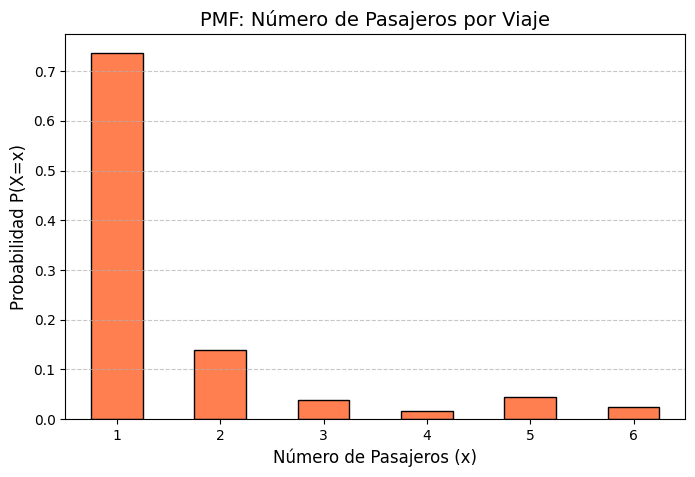

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar la base de datos
df = sns.load_dataset('taxis').dropna()

# Limpiamos anomalías (viajes con 0 pasajeros registrados por error del sensor)
df = df[df['passengers'] > 0]

# ==========================================
# CÁLCULO DE LA PMF
# ==========================================
# En Pandas, value_counts(normalize=True) es literalmente la definición de la PMF
# Calcula la frecuencia relativa de cada valor discreto
pmf = df['passengers'].value_counts(normalize=True).sort_index()

print("--- Función de Masa de Probabilidad p_X(x) ---")
for x, prob in pmf.items():
    print(f"P(X = {x}) = {prob:.4f} ({prob*100:.1f}%)")

# ==========================================
# VISUALIZACIÓN DE LA PMF
# ==========================================
# La regla de oro en visualización: las PMF siempre se grafican con barras, no con líneas continuas.
plt.figure(figsize=(8, 5))
pmf.plot(kind='bar', color='coral', edgecolor='black')

plt.title('PMF: Número de Pasajeros por Viaje', fontsize=14)
plt.xlabel('Número de Pasajeros (x)', fontsize=12)
plt.ylabel('Probabilidad P(X=x)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Problema 5: Reto Analítico para la Clase: Tomando Decisiones con la PMF

Ahora que tienen el mapa probabilístico del negocio frente a ustedes, resuelvan los siguientes dilemas operativos usando código:

**Problema 1: La Trampa del Promedio**
El gerente de operaciones calcula el promedio de la columna `passengers` y afirma: *"El promedio es de 1.5 pasajeros por viaje. Diseñemos la campaña de marketing asumiendo que la mayoría de nuestros viajes serán de parejas"*.
Observando la PMF, ¿por qué basarse en este promedio (Esperanza Matemática) es un error analítico fatal para el negocio?

**Problema 2: Justificando la Flota "XL"**
El equipo financiero argumenta que no deberíamos aceptar camionetas grandes (SUV de 6 puestos) en la plataforma porque consumen mucha gasolina. Usando la PMF, calculen matemáticamente: ¿Qué porcentaje exacto del mercado estaríamos perdiendo todos los días si limitamos nuestra flota exclusivamente a autos sedán estándar (capacidad máxima de 4 pasajeros)?

Acá tu respuesta

In [ ]:
#crea tu código

##Problema 6:



**Pregunta 1:** El gerente actual tiene todo el restaurante configurado con mesas fijas de 4 puestos. Si entra un grupo de 2, ocupan una mesa de 4 y se desperdician dos sillas. Usando solo las PMFs, ¿qué porcentaje de las mesas estarán desperdiciando espacio de lunes a viernes en comparación con el fin de semana?

**Pregunta 2:** Un proveedor ofrece un gran descuento por comprar mesas redondas masivas (de 6 puestos) que no se pueden separar. Argumenta que "los fines de semana vienen familias grandes". ¿Justifica la PMF esta inversión?

**Pregunta 3:** El chef quiere lanzar un menú especial para compartir "Familia de 4" los fines de semana, asumiendo que es el formato estrella. ¿Qué le dice la PMF del fin de semana sobre los grupos de 3 y 4 personas?

--- PMF: Probabilidad de Tamaño de Grupo (Entre Semana) ---
size
1    0.0247
2    0.7901
3    0.0617
4    0.0741
5    0.0123
6    0.0370
Name: proportion, dtype: object

--- PMF: Probabilidad de Tamaño de Grupo (Fin de Semana) ---
size
1    0.0123
2    0.5644
3    0.2025
4    0.1902
5    0.0245
6    0.0061
Name: proportion, dtype: object


<Figure size 1000x500 with 0 Axes>

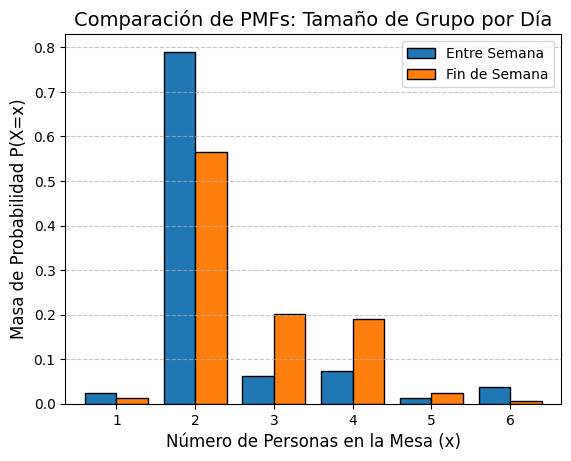

In [ ]:
# @title
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar la base de datos
df = sns.load_dataset('tips')

# Separar los datos en dos realidades de negocio
df_semana = df[df['day'].isin(['Thur', 'Fri'])]
df_finde = df[df['day'].isin(['Sat', 'Sun'])]

# Calcular la PMF para cada escenario
pmf_semana = df_semana['size'].value_counts(normalize=True).sort_index()
pmf_finde = df_finde['size'].value_counts(normalize=True).sort_index()

print("--- PMF: Probabilidad de Tamaño de Grupo (Entre Semana) ---")
print(pmf_semana.apply(lambda x: f"{x:.4f}"))

print("\n--- PMF: Probabilidad de Tamaño de Grupo (Fin de Semana) ---")
print(pmf_finde.apply(lambda x: f"{x:.4f}"))

# Gráfico comparativo para la evaluación
plt.figure(figsize=(10, 5))
datos_grafico = pd.DataFrame({'Entre Semana': pmf_semana, 'Fin de Semana': pmf_finde}).fillna(0)
datos_grafico.plot(kind='bar', edgecolor='black', width=0.8)

plt.title('Comparación de PMFs: Tamaño de Grupo por Día', fontsize=14)
plt.xlabel('Número de Personas en la Mesa (x)', fontsize=12)
plt.ylabel('Masa de Probabilidad P(X=x)', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

:::**Redacta acá tu respuesta**:::

#Aproximación de la densidad para variables continuas

## Histograma: Visualización de la Distribución de Variables Continuas

Un **histograma** es una herramienta gráfica que se utiliza para representar la distribución de una variable continua. Divide el rango de valores de la variable en una serie de intervalos (o 'bins') y cuenta cuántas observaciones caen en cada intervalo. La altura de cada barra en el histograma indica la frecuencia (o la densidad) de los datos en ese intervalo.

En los histogramas que hemos generado para el `total_bill` (el total de la cuenta) del dataset 'tips', podemos observar lo siguiente:

*   **Forma de la Distribución:** Ambas gráficas muestran una **asimetría positiva (o 'sesgo a la derecha')**. Esto significa que la cola de la distribución se extiende más hacia valores más altos (cuentas más grandes), mientras que la mayoría de los valores se concentran en el extremo inferior (cuentas más pequeñas). Esto es común en datos de ingresos o gastos, donde la mayoría de las transacciones son de bajo o mediano valor, y un pequeño número de transacciones son de alto valor.

*   **Conteo o Densidad:**
    *   El primer histograma (`Histograma para Total Bill`) muestra la **frecuencia absoluta** (el conteo) de cuentas en cada bin.
    *   El segundo histograma (`Comparación: Histograma vs KDE`) muestra la **densidad**, lo que significa que el área total bajo las barras (y bajo la curva KDE) suma 1, representando la probabilidad. Esta vista es útil para comparar la forma de la distribución, independientemente del número total de observaciones.

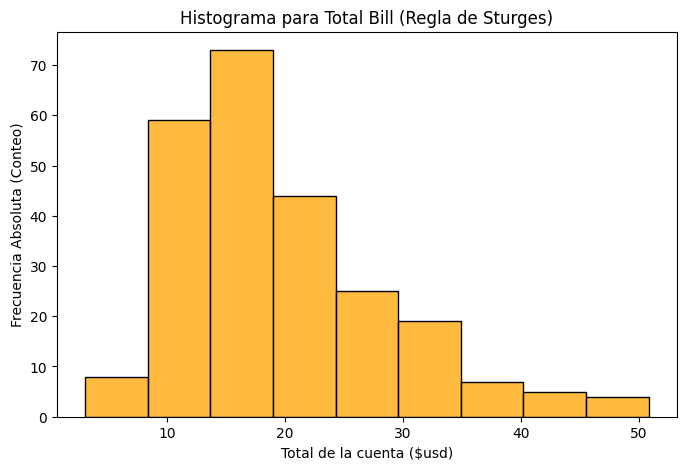

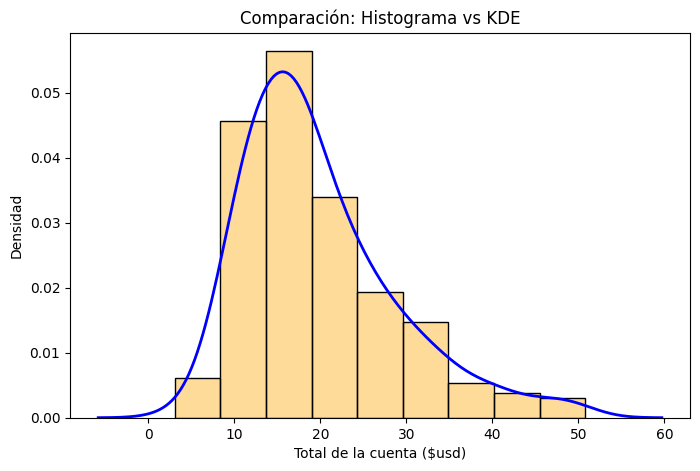

In [ ]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos el dataset 'tips' integrado en seaborn
df = sns.load_dataset("tips")

# 2. Extraemos la variable continua eliminando posibles valores nulos
cuentas = df['total_bill'].dropna()

# ==========================================
# GRÁFICO 1: Histograma (Aproximación Discreta)
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(data=cuentas, bins='sturges', color="orange")
plt.title("Histograma para Total Bill (Regla de Sturges)")
plt.xlabel("Total de la cuenta ($usd)")
plt.ylabel("Frecuencia Absoluta (Conteo)")
plt.show()

# ==========================================
# GRÁFICO 3: Histograma + KDE superpuestos
# ==========================================
plt.figure(figsize=(8, 5))
# Nota: stat="density" escala el histograma para que el área total sea 1 (probabilidad)
sns.histplot(data=cuentas, bins='sturges', color="orange", stat="density", alpha=0.4)
sns.kdeplot(data=cuentas, color="blue", bw_adjust=1.0, linewidth=2)
plt.title("Comparación: Histograma vs KDE")
plt.xlabel("Total de la cuenta ($usd)")
plt.ylabel("Densidad")
plt.show()

##Estimación por kernels

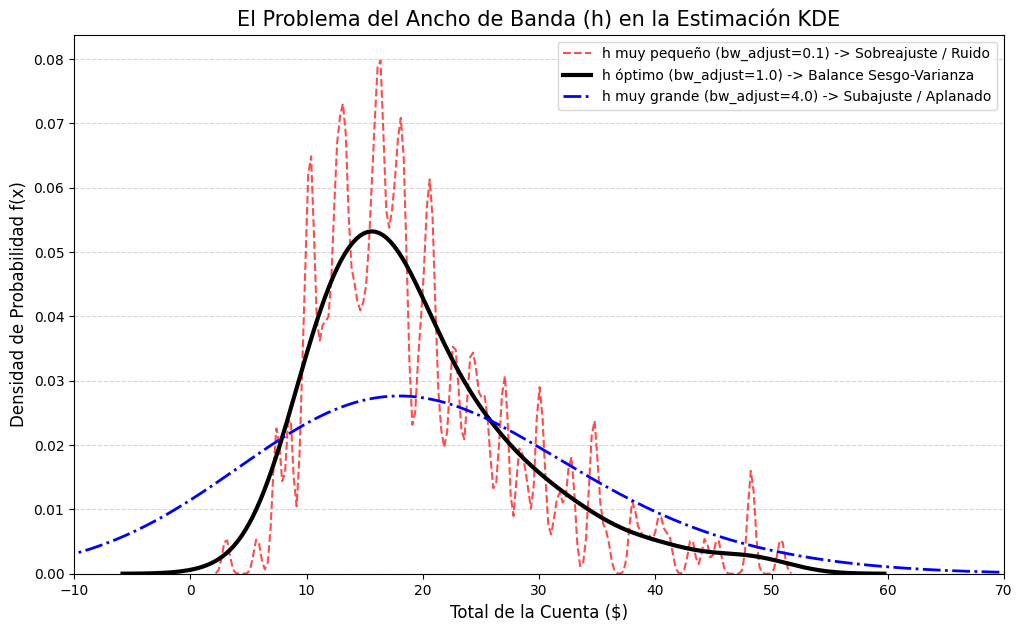

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar la base de datos de propinas
df = sns.load_dataset('tips')

# Configurar el lienzo
plt.figure(figsize=(12, 7))

# Escenario 1: Sobreajuste (h muy pequeño)
# Seaborn usa 'bw_adjust' para escalar el ancho de banda h
sns.kdeplot(data=df, x='total_bill', bw_adjust=0.1, color='red', linestyle='--',
            alpha=0.7, label='h muy pequeño (bw_adjust=0.1) -> Sobreajuste / Ruido')

# Escenario 2: El Balance Óptimo (h por defecto)
# Seaborn usa algoritmos como la regla de Scott o Silverman por defecto
sns.kdeplot(data=df, x='total_bill', bw_adjust=1.0, color='black', linewidth=3,
            label='h óptimo (bw_adjust=1.0) -> Balance Sesgo-Varianza')

# Escenario 3: Subajuste (h muy grande)
sns.kdeplot(data=df, x='total_bill', bw_adjust=4.0, color='blue', linestyle='-.',
            linewidth=2, label='h muy grande (bw_adjust=4.0) -> Subajuste / Aplanado')



# Estética del gráfico
plt.title('El Problema del Ancho de Banda (h) en la Estimación KDE', fontsize=15)
plt.xlabel('Total de la Cuenta ($)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.legend(fontsize=10)
plt.xlim(-10, 70)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##Problema 7:

**Pregunta:** Observe cómo ambas curvas (almuerzo y cena) no son simétricas como una campana de Gauss perfecta, sino que se estiran hacia la derecha. ¿Qué significa esto en términos de probabilidad continua?

**Pregunta:** Comparen el punto más alto (la moda matemática) de la curva del Almuerzo (Lunch) con la de la Cena (Dinner)

**Pregunta:** El gerente quiere lanzar una promoción: "Postre gratis en cuentas mayores a $30". ¿En qué turno esta promoción le costará más dinero al restaurante?

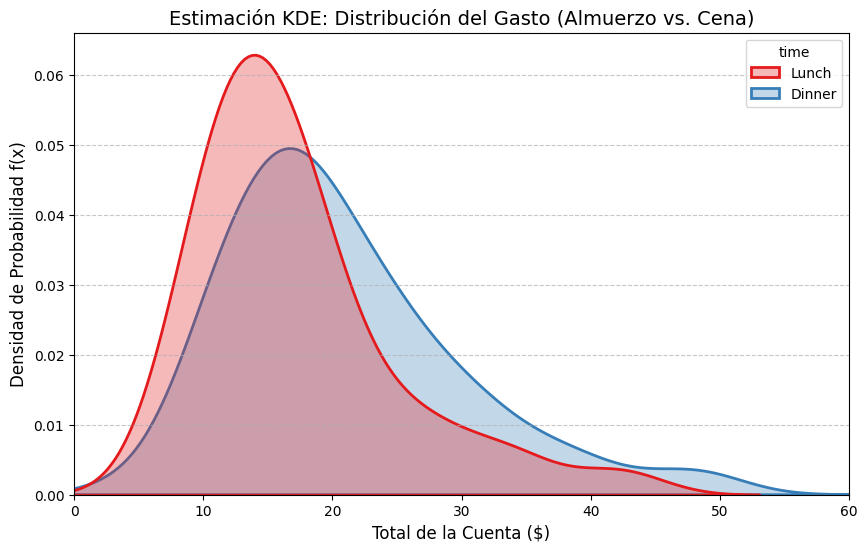

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar la base de datos de propinas
df = sns.load_dataset('tips')

# 2. Visualización: KDE Condicionado por el momento del día
plt.figure(figsize=(10, 6))

# Usamos hue='time' para que Seaborn calcule un KDE separado para Almuerzo y Cena
sns.kdeplot(data=df, x='total_bill', hue='time', common_norm=False,
            fill=True, alpha=0.3, linewidth=2, palette='Set1')

plt.title('Estimación KDE: Distribución del Gasto (Almuerzo vs. Cena)', fontsize=14)
plt.xlabel('Total de la Cuenta ($)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.xlim(0, 60) # Acotamos para ver mejor la campana principal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

:::**Redacta ru respuesta acá**:::

##Problema 8:

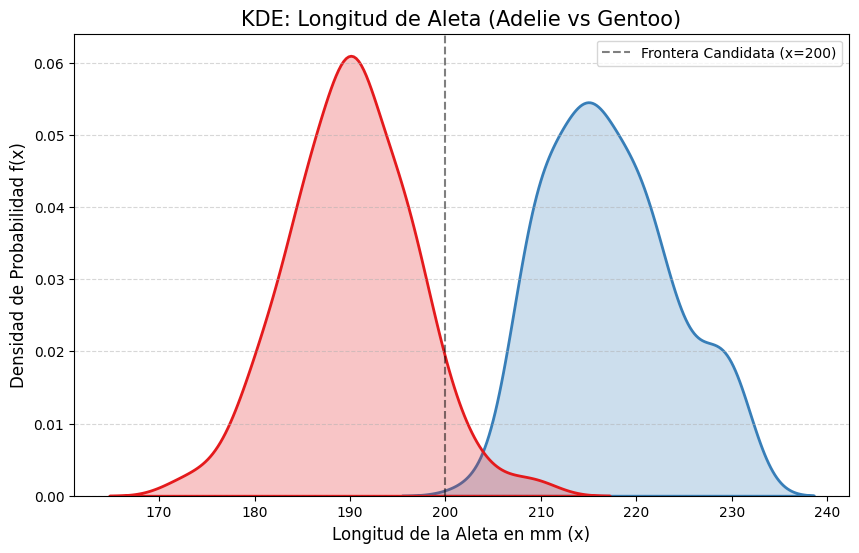

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar la base de datos y filtrar solo las dos especies de interés
df = sns.load_dataset('penguins').dropna()
df_filtrado = df[df['species'].isin(['Adelie', 'Gentoo'])]

# 2. Visualización: KDE superpuesto para ambas especies
plt.figure(figsize=(10, 6))

# Dibujamos las funciones de densidad f(x) para cada especie
sns.kdeplot(data=df_filtrado, x='flipper_length_mm', hue='species',
            fill=True, common_norm=False, linewidth=2, palette='Set1')



plt.title('KDE: Longitud de Aleta (Adelie vs Gentoo)', fontsize=15)
plt.xlabel('Longitud de la Aleta en mm (x)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.axvline(x=200, color='black', linestyle='--', alpha=0.5, label='Frontera Candidata (x=200)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



**Pregunta 1: La Intersección Matemática (El Umbral Óptimo)**
El código traza una línea punteada arbitraria en $x = 200$ mm como "frontera candidata". Todo lo que mida menos de 200 mm será clasificado como Adelie, y lo mayor a 200 mm como Gentoo. Viendo las curvas KDE, ¿es $x = 200$ el mejor umbral posible? Si no lo es, ¿cuál es el punto exacto ideal?

**Pregunta 2: El Costo del Error (El Área de Solapamiento)**
Por más perfecto que sea nuestro umbral en $x = 205$, el algoritmo se va a equivocar a veces. Identifique visualmente dónde están los "Falsos Positivos" y "Falsos Negativos" y cómo se calcularía su probabilidad matemáticamente.

**Pregunta 3: El Sabotaje del Ancho de Banda ($h$) en la Clasificación**
Modifiquen el código añadiendo un ancho de banda muy pequeño: `sns.kdeplot(..., bw_adjust=0.1)`. ¿Qué le pasa a nuestro umbral de decisión perfecto?

:::**Redacta acá tu respuesta**:::

#Estimación de la función de distribución acumulada

##Ejemplo

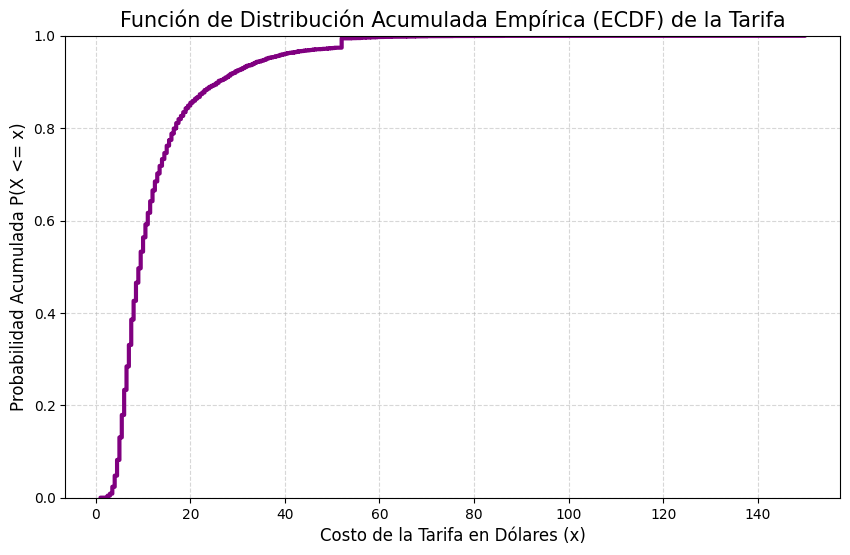

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Asegurarse de que 'tarifas' esté cargada, si no lo está
df = sns.load_dataset('taxis').dropna()
tarifas = df['fare']

plt.figure(figsize=(10, 6))

sns.ecdfplot(data=tarifas, color='purple', linewidth=3)

plt.title('Función de Distribución Acumulada Empírica (ECDF) de la Tarifa', fontsize=15)
plt.xlabel('Costo de la Tarifa en Dólares (x)', fontsize=12)
plt.ylabel('Probabilidad Acumulada P(X <= x)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

#Esperanza

##Aproximación de la Media Muestral a la Esperanza (Ley de los Grandes Números)

La **Ley de los Grandes Números** es un teorema fundamental en la teoría de la probabilidad que establece que, a medida que el tamaño de una muestra aleatoria aumenta, la media muestral de la muestra se acerca cada vez más a la media (valor esperado) de la población. En otras palabras, con suficientes observaciones, el promedio de los datos observados converge al promedio teórico.

Vamos a demostrar esto con un ejemplo sencillo: el lanzamiento de un dado justo de seis caras.

**1. Valor Esperado Teórico de un Dado Justo (E[X]):**
Para un dado justo, la probabilidad de obtener cualquier cara (1, 2, 3, 4, 5, 6) es $1/6$. El valor esperado se calcula como:

$E[X] = \sum_{i=1}^{6} x_i \cdot P(x_i) = 1(1/6) + 2(1/6) + 3(1/6) + 4(1/6) + 5(1/6) + 6(1/6) = 3.5$

Ahora, veremos cómo la media de los resultados de múltiples lanzamientos se acerca a 3.5.

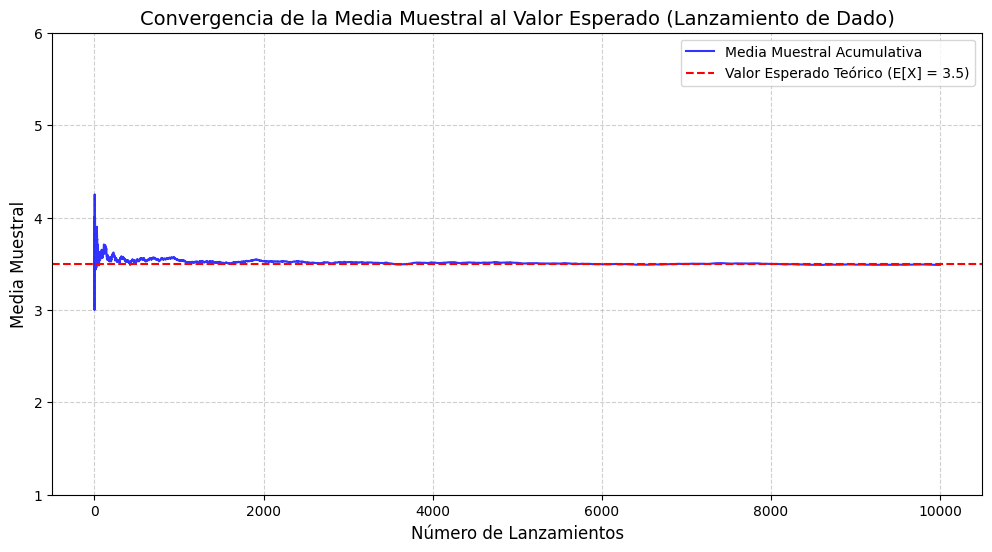

Después de 10000 lanzamientos, la media muestral es: 3.4878
El valor esperado teórico es: 3.5


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir el valor esperado teórico de un dado justo
expected_value = 3.5

# 2. Simular lanzamientos de un dado y calcular la media muestral
num_simulations = 10000  # Número total de lanzamientos
results = np.random.randint(1, 7, size=num_simulations) # Simula lanzamientos de dado (1 a 6)

# Calcular las medias muestrales acumulativas
sample_means = np.cumsum(results) / (np.arange(num_simulations) + 1)

# 3. Visualizar la convergencia
plt.figure(figsize=(12, 6))
plt.plot(sample_means, label='Media Muestral Acumulativa', color='blue', alpha=0.8)
plt.axhline(y=expected_value, color='red', linestyle='--', label=f'Valor Esperado Teórico (E[X] = {expected_value})')

plt.title('Convergencia de la Media Muestral al Valor Esperado (Lanzamiento de Dado)', fontsize=14)
plt.xlabel('Número de Lanzamientos', fontsize=12)
plt.ylabel('Media Muestral', fontsize=12)
plt.ylim(1, 6) # Rango de valores posibles de un dado
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Después de {num_simulations} lanzamientos, la media muestral es: {sample_means[-1]:.4f}")
print(f"El valor esperado teórico es: {expected_value}")

### Observación y Conclusión:

Como puedes observar en el gráfico, la línea azul (media muestral acumulativa) comienza muy errática con pocos lanzamientos, pero a medida que el número de lanzamientos aumenta, se estabiliza y se acerca cada vez más a la línea roja punteada (el valor esperado teórico de 3.5). Después de 10,000 lanzamientos, la media muestral está muy cerca de 3.5, confirmando la Ley de los Grandes Números.

##Problema 9

###El Escenario de Negocio: La Promoción "VIP Cashback"
El equipo de marketing quiere incentivar a los clientes a pedir platos más caros. Proponen una promoción agresiva: Si el total de la cuenta supera los 40, el restaurante le devolverá el 15% del valor de la cuenta en efectivo (Cashback). Si gastan 40 o menos, no reciben nada.

El gerente de finanzas necesita presupuestar esta campaña y pregunta: "¿Cuál será nuestro costo esperado (en Cashback) por cada mesa que entre al restaurante?"

In [ ]:
#Tu código
import seaborn as sns
import pandas as pd

# Cargar la base de datos histórica
df = sns.load_dataset('tips')


###Pregunta 1:
Un analista junior del equipo de finanzas dice: "Si el ticket promedio esperado del restaurante es de 19.79, y la promoción solo aplica si superan los 40, entonces ninguna mesa promedio alcanzará el descuento. ¡Por lo tanto, el costo esperado de la campaña debería ser cero!". ¿Dónde está el error matemático del analista?

###Pregunta 2:
Sabiendo que $E[g(X)] \approx 0.28$, si el restaurante proyecta atender a 10,000 mesas este año, ¿cuánto dinero en efectivo deben guardar en el banco hoy para financiar esta promoción sin quedarse sin liquidez?

#Varianza



###El Escenario de Negocio: Midiendo el Riesgo (Volatilidad de Ingresos)

**Pregunta** El gerente ya sabe que espera recibir 19.79 dólares por mesa en promedio ($E[X]$). Ahora el banco le pregunta: "¿Qué tan predecible es ese ingreso? ¿Esos 19.79 son estables como un reloj suizo, o un día reciben 5 dólares y al siguiente 50?

In [ ]:
# Tu código

#Cuantiles

##Problema 11
**Pregunta:** La aplicación de movilidad quiere premiar a los conductores que realicen viajes extraordinariamente rentables. El CEO lanza un decreto: "A partir de hoy, cualquier viaje que se considere 'Premium' recibirá un bono especial. Definan 'Premium' como el 5% de los viajes más caros de la ciudad".

**Pregunta:** Un analista junior, usando lo que aprendió en su primera clase, dice: "Fácil. Tomamos la media, le sumamos dos desviaciones estándar, y todo lo que esté por encima de eso es nuestro umbral Premium".

In [ ]:
#tu código
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Cargar la base de datos de taxis (columna de tarifa 'fare')
df = sns.load_dataset('taxis').dropna()
tarifas = df['fare']



::**Acá tu respuesta**::

**Pregunta**
¿Por qué la regla del analista junior (Media + 2 Desviaciones) falló en encontrar el 5% exacto? Haga un histograma o un kde de la variable fare para fundamentar su respuesta

In [ ]:
#Tu código acá



**Pregunta**: Sabiendo que la Varianza se contamina fácilmente con viajes de $150 dólares, si queremos medir la "dispersión real" o el comportamiento típico de la mayoría de los viajes sin que los valores extremos nos mientan, ¿qué métrica basada en cuantiles usarían? Calcule y compare los resultados con la varianza

In [ ]:
#Tu codigo

**Pregunta** Mire la curva azul del gráfico (la ECDF). Sube rapidísimo al principio y luego se aplana y avanza lentamente hacia la derecha. ¿Qué significa esa geometría en términos de probabilidad y facturación?

:::**Respuesta**:::

#Distribución de Bernoulli

El Escenario de Negocio: El Detector de Terminales Rotas

En Nueva York, es extremadamente raro que un pasajero pague su viaje con tarjeta de crédito y deje exactamente $0.00 de propina. Cuando esto ocurre repetidamente, la empresa asume que la pantalla táctil para dejar propinas en ese taxi está rota (o que el conductor está cometiendo algún tipo de fraude).

Definimos nuestra variable aleatoria de Bernoulli, $X$, para un viaje pagado con tarjeta:

$X = 1$ (Éxito/Anomalía): La propina es exactamente $0.00.$

$X = 0$ (Fracaso/Normalidad): La propina es mayor a $0.00.

El objetivo es extraer el parámetro $p$ directamente de los datos históricos y usar las propiedades teóricas de la distribución ($E[X]$ y $Var(X)$) para auditar la flota.

In [ ]:
import seaborn as sns
import pandas as pd

# 1. Cargar la base de datos y aislar el universo de interés (pagos con tarjeta)
df = sns.load_dataset('taxis').dropna()
df_tarjetas = df[df['payment'] == 'credit card'].copy()



##Problema 12

**Pregunta:** Si $p = 0.0988$ es el comportamiento base (la terminal se traba ocasionalmente o un cliente genuinamente no quiere dar propina), ¿cómo usarían esta variable de Bernoulli para detectar a un conductor específico que está desconectando la terminal a propósito?
calculamos un único parámetro $p$ para toda la ciudad, asumimos que todos los taxis operan bajo la misma "moneda sesgada".

Demostraremos que el parámetro $p$ de la distribución de Bernoulli muta dependiendo del distrito de origen, revelando que el riesgo de fraude o fallo técnico no se distribuye de manera uniforme.

¿Cuál es el valor de p para cada barrio?

In [ ]:
## Tu código acá

**Pregunta**: La probabilidad marginal global que calculamos antes era $P(X=1) \approx 0.098$. Un auditor revisa un taxi al azar y tiene esa expectativa de encontrar una terminal rota. Si de repente le decimos que el taxi viene del Bronx, ¿cómo cambia su modelo mental del problema?

::**Respuesta**::

**Pregunta**: Calcule la varianza para cada Barrio. Notarán que la varianza en el Bronx es matemáticamente diferente a la varianza en Manhattan. ¿Por qué esto es una pesadilla para un analista que intenta usar modelos predictivos tradicionales (como regresiones lineales clásicas)?

**Pregunta** El gerente de operaciones de la flota solo tiene presupuesto para enviar auditores a revisar 15 terminales de taxi esta semana. Basándose en la tabla, el Bronx tiene la mayor tasa de anomalías (el $p$ más alto), pero Manhattan tiene el mayor volumen total absoluto de anomalías (sumando cientos debido a la cantidad masiva de viajes). ¿A dónde envían a los auditores y por qué?

**Respuesta**

#Distribución Binomial

Supongamos que, del ejercicio anterior, descubrimos empíricamente que la probabilidad de que un taxi en Manhattan tenga la terminal rota (o esté cometiendo fraude de propinas) es del $3\%$ ($p = 0.03$).

El gerente de operaciones envía a un auditor a la estación de Penn Station en Manhattan con una orden clara: "Revisa exactamente $50$ taxis al azar".

Definimos nuestra variable aleatoria $X$ como el número total de terminales rotas encontradas en esa muestra.

$$X \sim \text{Binomial}(n=50, p=0.03)$$

--- Auditoría de 50 Taxis (p=0.03) ---
Probabilidad de encontrar exactamente 0 terminal(es) rota(s): 0.2181 (21.8%)
Probabilidad de encontrar exactamente 1 terminal(es) rota(s): 0.3372 (33.7%)
Probabilidad de encontrar exactamente 2 terminal(es) rota(s): 0.2555 (25.6%)
Probabilidad de encontrar exactamente 3 terminal(es) rota(s): 0.1264 (12.6%)
Probabilidad de encontrar exactamente 4 terminal(es) rota(s): 0.0459 (4.6%)
Probabilidad de encontrar exactamente 5 terminal(es) rota(s): 0.0131 (1.3%)


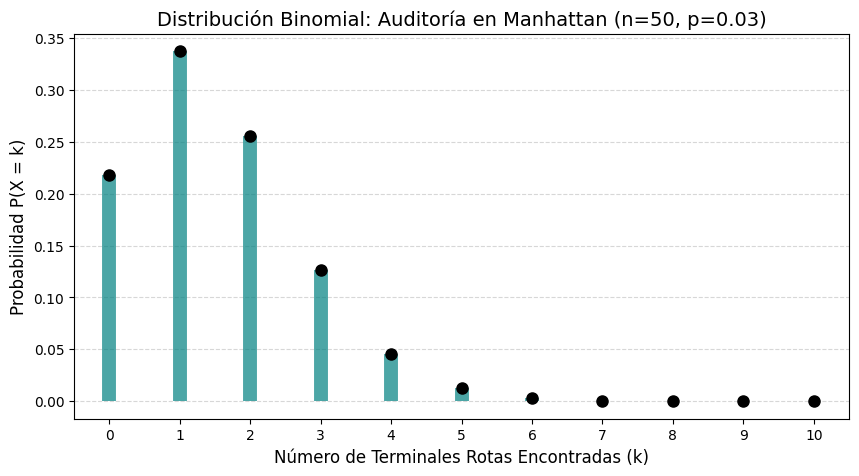

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ==========================================
# 1. Definición de los Parámetros del Modelo
# ==========================================
n_taxis = 50       # Tamaño de la muestra (n ensayos)
p_anomalia = 0.03  # Probabilidad de éxito empírica de Manhattan (p)

# Definimos el espacio muestral k (de 0 a 10 es suficiente, más allá la prob es casi 0)
k_valores = np.arange(0, 11)

# ==========================================
# 2. Cálculo de la PMF Binomial
# ==========================================
# pmf(k, n, p) calcula la probabilidad exacta de encontrar 'k' terminales rotas
probabilidades = binom.pmf(k_valores, n_taxis, p_anomalia)

print(f"--- Auditoría de {n_taxis} Taxis (p={p_anomalia}) ---")
for k, prob in zip(k_valores[:6], probabilidades[:6]): # Mostramos solo hasta k=5
    print(f"Probabilidad de encontrar exactamente {k} terminal(es) rota(s): {prob:.4f} ({prob*100:.1f}%)")

# ==========================================
# 3. Visualización de la PMF
# ==========================================
plt.figure(figsize=(10, 5))
# Usamos un gráfico de barras (vlines) porque es una variable discreta
plt.vlines(k_valores, 0, probabilidades, colors='teal', lw=10, alpha=0.7)
plt.plot(k_valores, probabilidades, 'o', color='black', markersize=8)

plt.title(f'Distribución Binomial: Auditoría en Manhattan (n={n_taxis}, p={p_anomalia})', fontsize=14)
plt.xlabel('Número de Terminales Rotas Encontradas (k)', fontsize=12)
plt.ylabel('Probabilidad P(X = k)', fontsize=12)
plt.xticks(k_valores)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##Problema 12:

**Pregunta:**
El auditor regresa al final del día y reporta: "Revisé 50 taxis y encontré $1$ terminal rota". El gerente se enfurece y le dice: "¡Es imposible! Manhattan está lleno de taxis defectuosos, no hiciste bien tu trabajo". Usando la PMF que acaban de generar, ¿cómo defiende matemáticamente al auditor?

:::**Respuesta**::

**Pregunta** El contrato con la empresa que repara las terminales dice: "Si en una auditoría aleatoria de 50 taxis se encuentran 4 o más terminales rotas, se aplicará una multa millonaria por incumplimiento". El proveedor de mantenimiento está asustado de que la "mala suerte" los haga pagar la multa, a pesar de que la tasa global real se mantiene en el 3%. ¿Cuál es la probabilidad de que la empresa sea multada injustamente por pura varianza estadística?

In [ ]:
## Tu Código

:::**Respuesta**:::

# Distribución Poisson

###El Escenario de Negocio: Optimización de Flota en el Aeropuerto JFK

La empresa de taxis tiene un problema de asignación de recursos. El gerente de la terminal del aeropuerto JFK necesita saber cuántos taxis debe tener estacionados en la fila de espera cada 10 minutos durante la hora pico de la mañana. El equipo de analítica de datos ha extraído una métrica histórica fundamental: en promedio, llegan $\lambda = 4$ pasajeros a la fila cada 10 minutos buscando un taxi.
El Problema: Si el gerente envía exactamente 4 taxis cada 10 minutos (guiándose solo por el promedio), ¿qué pasa si en un intervalo de 10 minutos "por mala suerte" llegan 7 pasajeros? Se formará una cola, habrá quejas y perderán clientes frente a Uber.

--- Demanda en JFK (λ = 4.0 pasajeros / 10 min) ---
Probabilidad de que lleguen exactamente 0 pasajeros: 0.0183 (1.8%)
Probabilidad de que lleguen exactamente 1 pasajeros: 0.0733 (7.3%)
Probabilidad de que lleguen exactamente 2 pasajeros: 0.1465 (14.7%)
Probabilidad de que lleguen exactamente 3 pasajeros: 0.1954 (19.5%)
Probabilidad de que lleguen exactamente 4 pasajeros: 0.1954 (19.5%)
Probabilidad de que lleguen exactamente 5 pasajeros: 0.1563 (15.6%)
Probabilidad de que lleguen exactamente 6 pasajeros: 0.1042 (10.4%)
Probabilidad de que lleguen exactamente 7 pasajeros: 0.0595 (6.0%)

Riesgo de colapso (> 6 pasajeros): 0.1107 (11.1%)


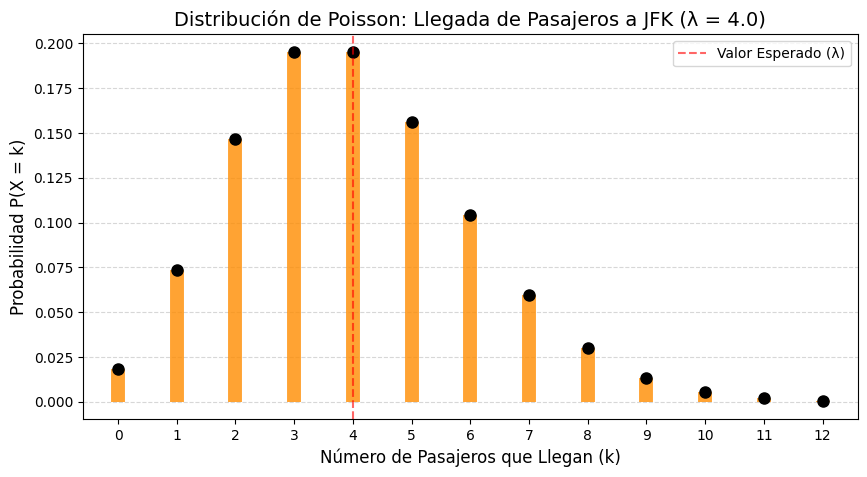

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# ==========================================
# 1. Parámetro de la Distribución
# ==========================================
# Lambda (λ): Tasa promedio de eventos en nuestro intervalo de tiempo
tasa_llegadas_lambda = 4.0

# Definimos los posibles escenarios (llegadas de 0 hasta 12 pasajeros)
k_pasajeros = np.arange(0, 13)

# ==========================================
# 2. Cálculo de la PMF de Poisson
# ==========================================
# Matemáticamente: P(X=k) = (e^-λ * λ^k) / k!
probabilidades = poisson.pmf(k_pasajeros, tasa_llegadas_lambda)

print(f"--- Demanda en JFK (λ = {tasa_llegadas_lambda} pasajeros / 10 min) ---")
for k, prob in zip(k_pasajeros[:8], probabilidades[:8]):
    print(f"Probabilidad de que lleguen exactamente {k} pasajeros: {prob:.4f} ({prob*100:.1f}%)")

# Probabilidad de un pico extremo de demanda (más de 6 pasajeros)
# Usamos 1 - CDF(6) para calcular la cola derecha
prob_pico_extremo = 1 - poisson.cdf(6, tasa_llegadas_lambda)
print(f"\nRiesgo de colapso (> 6 pasajeros): {prob_pico_extremo:.4f} ({prob_pico_extremo*100:.1f}%)")

# ==========================================
# 3. Visualización de la Distribución
# ==========================================
plt.figure(figsize=(10, 5))
plt.vlines(k_pasajeros, 0, probabilidades, colors='darkorange', lw=10, alpha=0.8)
plt.plot(k_pasajeros, probabilidades, 'o', color='black', markersize=8)



plt.title(f'Distribución de Poisson: Llegada de Pasajeros a JFK (λ = {tasa_llegadas_lambda})', fontsize=14)
plt.xlabel('Número de Pasajeros que Llegan (k)', fontsize=12)
plt.ylabel('Probabilidad P(X = k)', fontsize=12)
plt.xticks(k_pasajeros)
plt.axvline(x=tasa_llegadas_lambda, color='red', linestyle='--', alpha=0.6, label='Valor Esperado (λ)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Pregunta:** El gerente dice: "Perfecto, el promedio es 4, así que enviaré 4 taxis cada 10 minutos. Con eso cubro la demanda matemática". Usando la distribución generada, ¿cuál es la probabilidad exacta de que haya clientes enojados esperando porque no hay suficientes taxis?

In [ ]:
# tu código

:::**Respuesta**:::

**Pregunta:** Observen la forma de la campana. Está anclada en el 0 (no pueden llegar pasajeros negativos) y se estira hacia la derecha. Matemáticamente, en la distribución de Poisson, la Esperanza y la Varianza son idénticas: $E[X] = Var(X) = \lambda$. ¿Qué significa esto para un negocio si la demanda crece de $\lambda=4$ a $\lambda=20$ en la temporada de Navidad?

:::**Respuesta**:::

#Distribución Uniforme

###El Escenario de Negocio: El "Timeout" de una API de Machine Learning

El equipo de ingeniería acaba de desplegar en producción un modelo de Deep Learning que clasifica imágenes en tiempo real.
Revisando los logs del servidor, descubren que el tiempo que tarda la tarjeta gráfica (GPU) en procesar la imagen no sigue una curva normal. Debido a la arquitectura de la red y la memoria caché, el tiempo de respuesta varía aleatoriamente pero siempre cae estrictamente entre un mínimo de 200 ms ($a$) y un máximo de 800 ms ($b$), con cualquier valor intermedio siendo igualmente posible.
El Problema: Si el servidor espera demasiado tiempo por la respuesta, el sistema colapsa por acumulación de usuarios. Si el servidor corta la conexión muy rápido (el famoso Timeout), el usuario recibe un error a pesar de que la GPU estaba a punto de terminar. Sus estudiantes deben usar la función de densidad $f(x)$ y la función acumulada $F(x)$ para encontrar el límite de tiempo perfecto.

--- Auditoría de Tiempos de Respuesta de la API ---
Media empírica de los logs: 496.5 ms
Esperanza teórica E[X]: 500.0 ms



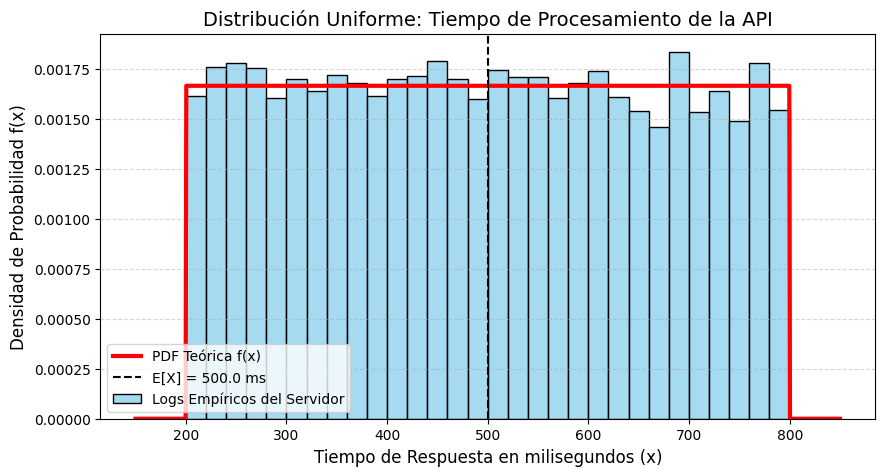

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Definición de Parámetros (El Servidor)
# ==========================================
a = 200  # Tiempo mínimo de respuesta (ms)
b = 800  # Tiempo máximo de respuesta (ms)

# Simulamos 10,000 peticiones a la API
np.random.seed(42)
logs_api = np.random.uniform(a, b, size=10000)

# ==========================================
# 2. Análisis Estadístico Descriptivo
# ==========================================
media_empirica = logs_api.mean()
# Teóricamente: E[X] = (a + b) / 2
esperanza_teorica = (a + b) / 2

print("--- Auditoría de Tiempos de Respuesta de la API ---")
print(f"Media empírica de los logs: {media_empirica:.1f} ms")
print(f"Esperanza teórica E[X]: {esperanza_teorica:.1f} ms\n")

# ==========================================
# 3. Visualización: La "Caja" de la Uniforme
# ==========================================
plt.figure(figsize=(10, 5))

# Histograma de los datos reales
sns.histplot(logs_api, bins=30, stat='density', color='skyblue',
             edgecolor='black', label='Logs Empíricos del Servidor')

# Dibujamos la Función de Densidad de Probabilidad Teórica f(x)
# f(x) = 1 / (b - a)
altura_fx = 1 / (b - a)
x_teorico = np.linspace(a - 50, b + 50, 1000)
y_teorico = [altura_fx if a <= x <= b else 0 for x in x_teorico]

plt.plot(x_teorico, y_teorico, color='red', lw=3, label='PDF Teórica f(x)')



plt.title('Distribución Uniforme: Tiempo de Procesamiento de la API', fontsize=14)
plt.xlabel('Tiempo de Respuesta en milisegundos (x)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.axvline(x=esperanza_teorica, color='black', linestyle='--', label=f'E[X] = {esperanza_teorica} ms')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Pregunta:**
El gerente de infraestructura ve el reporte que dice $E[X] = 500$ ms. Decide configurar el Timeout del servidor exactamente en 500 ms. Usando la intuición de la distribución uniforme, ¿qué porcentaje de los usuarios verán fallar su aplicación hoy?

:::**Respuesta**:::


**Pregunta** El equipo de ventas ha firmado un contrato (SLA) que garantiza que el 90% de las peticiones a la API se completarán sin errores. Como científicos de datos, ¿en cuántos milisegundos exactos deben configurar el Timeout para cumplir la promesa sin desperdiciar un milisegundo extra de servidor?

In [ ]:
# tu código

:::**Respuesta**:::


**Pregunta**: Otro equipo logró optimizar un segundo modelo de Machine Learning. El nuevo modelo tiene un tiempo de respuesta normal (campana de Gauss) con media de 500 ms y casi todos sus datos caen entre 400 y 600 ms. Si ambos modelos tienen exactamente la misma Esperanza ($E[X] = 500$), ¿por qué el primer modelo (Uniforme) es mucho más peligroso para el negocio?

:::**Respuesta**:::

# Distribución Normal

##El Escenario de Negocio: El "Value at Risk" (VaR)

Imagine que  son científicos de datos en un fondo de cobertura (Hedge Fund). El fondo maneja un portafolio de acciones valorado en 10 millones de dólares. A través de datos históricos, saben que el retorno diario de este portafolio sigue una distribución normal:


*   Media ($\mu$): 0.1% (En un día promedio, ganan un poco de dinero).
* Volatilidad ($\sigma$): 1.5% (El mercado fluctúa diariamente).







**Pregunta:** El CEO del fondo los llama a su oficina y les hace la pregunta más crítica de las finanzas: "Quiero dormir tranquilo. Con un nivel de confianza del 99%, ¿cuál es la máxima cantidad de dinero que podríamos perder mañana en un solo día?"

--- Reporte de Riesgo para el CEO (VaR Diario) ---
Retorno crítico (Umbral del 1%): -3.39%
Valor en Riesgo (VaR al 99%): $338,952.18 dólares



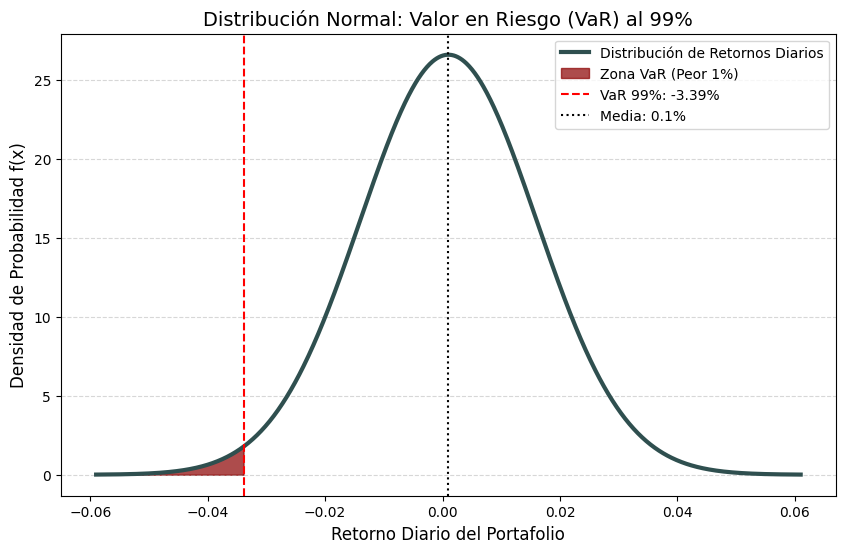

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Parámetros del Portafolio
# ==========================================
valor_portafolio = 10_000_000  # En dólares
mu = 0.001                     # Retorno medio diario (0.1%)
sigma = 0.015                  # Volatilidad diaria (1.5%)
nivel_confianza = 0.99         # Nivel de confianza (99%)
alfa = 1 - nivel_confianza     # El 1% de los peores escenarios

# ==========================================
# 2. El Cálculo Directo
# ==========================================
# Usamos ppf() pasando directamente la media (loc) y la desviación (scale).
# El algoritmo busca internamente el valor X que deja el 1% de área a su izquierda.
retorno_peor_escenario = stats.norm.ppf(alfa, loc=mu, scale=sigma)

# ==========================================
# 3. Traducción a Dólares (Cálculo del VaR)
# ==========================================
perdida_maxima_esperada = valor_portafolio * retorno_peor_escenario

print("--- Reporte de Riesgo para el CEO (VaR Diario) ---")
print(f"Retorno crítico (Umbral del 1%): {retorno_peor_escenario * 100:.2f}%")
print(f"Valor en Riesgo (VaR al 99%): ${abs(perdida_maxima_esperada):,.2f} dólares\n")

# ==========================================
# 4. Visualización Directa de la Cola Izquierda
# ==========================================
plt.figure(figsize=(10, 6))

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, y, color='darkslategray', lw=3, label='Distribución de Retornos Diarios')

# Sombreamos el área de desastre financiero
x_var = np.linspace(mu - 4*sigma, retorno_peor_escenario, 500)
y_var = stats.norm.pdf(x_var, loc=mu, scale=sigma)
plt.fill_between(x_var, 0, y_var, color='darkred', alpha=0.7, label='Zona VaR (Peor 1%)')



plt.axvline(retorno_peor_escenario, color='red', linestyle='--', label=f'VaR 99%: {retorno_peor_escenario*100:.2f}%')
plt.axvline(mu, color='black', linestyle=':', label=f'Media: {mu*100:.1f}%')

plt.title('Distribución Normal: Valor en Riesgo (VaR) al 99%', fontsize=14)
plt.xlabel('Retorno Diario del Portafolio', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Pregunta** ¿Qué esta haciendo el código de arriba?

:::**Respuesta**:::


**Pregunta:** El CEO lee el reporte y dice: "Perfecto, entonces me están garantizando que mañana no perderemos más de 338,900 dólares, ¿verdad?"

:::**Respuesta**:::

**Pregunta:** Sin escribir código, ¿qué pasaría matemáticamente con nuestro límite del VaR si mañana hay pánico en Wall Street y nuestra volatilidad ($\sigma$) se duplica repentinamente al 3.0%, pero el promedio ($\mu$) se mantiene igual?

:::**Respuesta**:::

#Distribución Exponencial

###El Escenario de Negocio: La Caída del Clúster de Servidores
Supongamos que el equipo de arquitectura de datos de una gran empresa de e-commerce administra un clúster masivo de servidores en la nube. Han notado que los servidores no se desgastan por la edad física (como un engranaje), sino que fallan por "choques aleatorios" (picos de voltaje, errores de memoria, o bugs en el sistema operativo). Al no haber desgaste acumulativo, la probabilidad de fallo es constante en el tiempo, lo que convierte al tiempo de vida del servidor en una variable aleatoria exponencial: $X \sim \text{Exp}(\lambda)$. El proveedor de la nube les garantiza un MTBF de 45 días. Es decir, en promedio, un nodo del clúster se cae cada 45 días ($E[X] = 45$). Por lo tanto, la tasa de fallos diaria es $\lambda = \frac{1}{45}$.

El equipo comercial va a lanzar una campaña masiva de ventas que durará un mes entero (30 días). El Director de Tecnología (CTO) necesita saber cuál es la probabilidad matemática de que el clúster sobreviva toda la campaña sin experimentar una sola caída crítica.

In [ ]:
#Tu código


**Problema:** El CTO se enfurece y dice: "¡El proveedor prometió que los servidores duran 45 días en promedio! ¿Cómo es posible que tengamos casi un 50% de probabilidad de que se caiga antes del día 30?"¿Está en lo cierto?

In [ ]:
## tu codigo

:::**Respuesta**:::



**Pregunta:** Llegamos al día 29 de la campaña y el servidor no ha fallado. El equipo de sistemas sugiere apagar el servidor en la madrugada, reiniciarlo y limpiar la memoria caché para "reiniciar el reloj" y evitar que se caiga el día 30. Matemáticamente, bajo un modelo exponencial estricto, ¿sirve de algo esta maniobra?

:::***Respuesta**:::

**Pregunta:** El CTO concluye que un 51.34% de supervivencia es inaceptable. Como científicos de datos, les exige una arquitectura que garantice al menos un 95% de probabilidad de supervivencia durante la campaña.

:::**Respuesta**::

#Distribución Gamma

##El Escenario de Negocio: La Política de los "3 Strikes"

El mismo proveedor de la nube del ejercicio anterior quiere retener el contrato. Le ofrecen al Director de Tecnología (CTO) una nueva arquitectura: un clúster de base de datos con 3 fuentes de poder redundantes ($k=3$). El servidor solo se apaga permanentemente si las 3 fuentes de poder se queman de forma consecutiva (falla la primera, entra la segunda; falla la segunda, entra la tercera; falla la tercera, colapso total). Si sabemos que el tiempo de vida de cada fuente de poder sigue una distribución Exponencial con un promedio de 45 días ($\lambda = \frac{1}{45}$), debe modelar la supervivencia del sistema completo.

--- Auditoría de Arquitectura Redundante ---
MTBF de un solo componente: 45.0 días
Esperanza de vida del clúster (k=3): 135.0 días


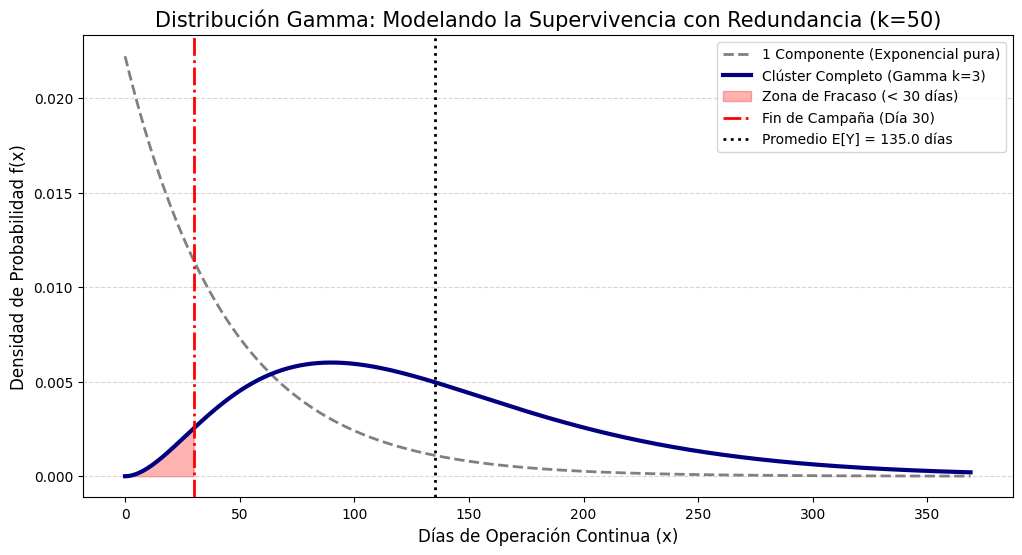

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Parámetros de Confiabilidad (SLA Redundante)
# ==========================================
mtbf_individual = 45.0  # Días promedio por componente (1/λ)
lambda_fallo = 1 / mtbf_individual

# El parámetro de forma (k) en la distribución Gamma
k_fallos = 3 # Modificado a 50 componentes para este problema

# ==========================================
# 2. Análisis del Sistema Completo (Teórico)
# ==========================================
# Esperanza matemática de la suma: E[Y] = k * E[X] = k / λ
esperanza_gamma = k_fallos * mtbf_individual

# Probabilidad de que el sistema sobreviva la campaña de 30 días
# Usamos sf (Survival Function = 1 - CDF)
prob_supervivencia = stats.gamma.sf(30, a=k_fallos, scale=mtbf_individual)

print("--- Auditoría de Arquitectura Redundante ---")
print(f"MTBF de un solo componente: {mtbf_individual} días")
print(f"Esperanza de vida del clúster (k={k_fallos}): {esperanza_gamma} días")


# ==========================================
# 3. Visualización: El Poder de la Redundancia
# ==========================================
plt.figure(figsize=(12, 6))
x_dias = np.linspace(0, esperanza_gamma + 3 * np.sqrt(k_fallos * mtbf_individual**2), 1000) # Ajustar el rango del eje x para k=50

# Curva 1: El componente individual (Exponencial, k=1)
y_exponencial = stats.gamma.pdf(x_dias, a=1, scale=mtbf_individual)
plt.plot(x_dias, y_exponencial, color='gray', linestyle='--', lw=2,
         label='1 Componente (Exponencial pura)')

# Curva 2: El sistema completo (Gamma, k=50)
y_gamma = stats.gamma.pdf(x_dias, a=k_fallos, scale=mtbf_individual)
plt.plot(x_dias, y_gamma, color='navy', lw=3,
         label=f'Clúster Completo (Gamma k={k_fallos})')



# Zonas de interés
plt.fill_between(x_dias, 0, y_gamma, where=(x_dias <= 30),
                 color='red', alpha=0.3, label='Zona de Fracaso (< 30 días)')

plt.axvline(30, color='red', linestyle='-.', lw=2, label='Fin de Campaña (Día 30)')
plt.axvline(esperanza_gamma, color='black', linestyle=':', lw=2,
            label=f'Promedio E[Y] = {esperanza_gamma} días')

plt.title('Distribución Gamma: Modelando la Supervivencia con Redundancia (k=50)', fontsize=15)
plt.xlabel('Días de Operación Continua (x)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Pregunta:** ¿Cual es la probabilidad de sobrevivir la campaña de 30 días?

In [ ]:
#Tu código

:::**Respuesta**:::

**Pregunta:** Observen dónde empieza la curva azul (la Gamma) en comparación con la línea gris punteada (la Exponencial). La Exponencial arranca en su punto más alto en $x=0$, pero la Gamma arranca en cero y sube gradualmente. ¿Qué significa este cambio geométrico para el negocio?

:::**Respuesta**:::


**Pregunta:** El punto más alto de la curva azul (la moda, el escenario más probable para el colapso final) no ocurre en el promedio ($E[Y] = 135$ días), sino antes. Matemáticamente, la moda de la Gamma es $(k - 1) \lambda^{-1}$. Calcule exactamente donde ocurre el pico e interprete

:::**Respuesta**:::



 **Pregunta:** Imaginen (o modifiquen el código) para un sistema hiper-redundante con $k=50$ componentes (por ejemplo, el desgaste de 50 engranajes sucesivos). ¿Qué forma tomará la curva azul a medida que $k$ crece hacia el infinito?

In [ ]:
#Tu código

:::**Respuesta**:::